In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1=pd.read_csv('hr_employee_churn_data.csv')   

In [3]:
df1.head()
        

,empid,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,left
0,1,0.38,0.53,2,157,3,0,0,low,1
1,2,0.80,0.86,5,262,6,0,0,medium,1
2,3,0.11,0.88,7,272,4,0,0,medium,1
3,4,0.72,0.87,5,223,5,0,0,low,1
4,5,0.37,0.52,2,159,3,0,0,low,1


In [4]:
# check the num of rows and columns in dataframe
df1.shape

(14999, 10)

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   empid                  14999 non-null  int64  
 1   satisfaction_level     14997 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   salary                 14999 non-null  object 
 9   left                   14999 non-null  int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 1.1+ MB


## FEATURE ENGINEERING

In [6]:
df2=df1.copy()

In [ ]:
df2.drop(['empid'],axis=1,inplace=True)

In [7]:
df2.head()

,empid,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,left
0,1,0.38,0.53,2,157,3,0,0,low,1
1,2,0.80,0.86,5,262,6,0,0,medium,1
2,3,0.11,0.88,7,272,4,0,0,medium,1
3,4,0.72,0.87,5,223,5,0,0,low,1
4,5,0.37,0.52,2,159,3,0,0,low,1


In [8]:
#handle missing values
df2.isnull().sum()

empid                    0
satisfaction_level       2
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
salary                   0
left                     0
dtype: int64

In [9]:
df2['satisfaction_level'].describe()

count    14997.000000
mean         0.612863
std          0.248634
min          0.090000
25%          0.440000
50%          0.640000
75%          0.820000
max          1.000000
Name: satisfaction_level, dtype: float64

In [ ]:
df2['satisfaction_level'].fillna(df2['satisfaction_level'].mean(), inplace=True)

In [11]:
df2.isnull().sum()


empid                    0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
salary                   0
left                     0
dtype: int64

In [12]:
df2['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

In [13]:
salary_dummies = pd.get_dummies(df2['salary'],drop_first=True)

In [14]:
salary_dummies

,low,medium
0,True,False
1,False,True
2,False,True
3,True,False
4,True,False
...,...,...
14994,True,False
14995,True,False
14996,True,False
14997,True,False


In [15]:
df2=pd.concat([df2,salary_dummies],axis=1)

In [16]:
df2.head()

,empid,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,left,low,medium
0,1,0.38,0.53,2,157,3,0,0,low,1,True,False
1,2,0.80,0.86,5,262,6,0,0,medium,1,False,True
2,3,0.11,0.88,7,272,4,0,0,medium,1,False,True
3,4,0.72,0.87,5,223,5,0,0,low,1,True,False
4,5,0.37,0.52,2,159,3,0,0,low,1,True,False


In [17]:
#drop salary feature as we already applied lable endcoding tech
df2.drop(['salary'],axis=1,inplace=True)

In [18]:
df2.head()

,empid,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,left,low,medium
0,1,0.38,0.53,2,157,3,0,0,1,True,False
1,2,0.80,0.86,5,262,6,0,0,1,False,True
2,3,0.11,0.88,7,272,4,0,0,1,False,True
3,4,0.72,0.87,5,223,5,0,0,1,True,False
4,5,0.37,0.52,2,159,3,0,0,1,True,False


## SPLIT THE DATASET 


In [19]:
X= df2.drop(labels='left',axis=1)
y= df2['left']
#split dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [22]:
len(X_train)


11999

In [23]:

len(X_test)

3000

## Model Selection 

In [26]:
# will try to use below two models that are RandomForestClassifier and XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [25]:
pip install xgboost


   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB 393.8 kB/s eta 0:04:14
   ---------------------------------------- 0.1/99.8 MB 655.4 kB/s eta 0:02:33
   ---------------------------------------- 0.3/99.8 MB 1.5 MB/s eta 0:01:08
   ---------------------------------------- 0.7/99.8 MB 2.9 MB/s eta 0:00:35
    --------------------------------------- 1.4/99.8 MB 5.1 MB/s eta 0:00:20
    --------------------------------------- 1.6/99.8 MB 5.7 MB/s eta 0:00:18
   - -------------------------------------- 2.7/99.8 MB 7.7 MB/s eta 0:00:13
   - -------------------------------------- 3.3/99.8 MB 7.9 MB/s eta 0:00:13
   - -------------------------------------- 3.9/99.8 MB 8.5 MB/s eta 0:00:12
   -- ------------------------------------- 5.2/99.8 MB 10.0 MB/s eta 0:00:10
   -- ---------

In [31]:
#create param
model_param = {
    'RandomForestClassifier': {
        'model': RandomForestClassifier(),
        'param': {
            'n_estimators': [10, 50, 100, 130], 
            'criterion': ['gini', 'entropy'],
            'max_depth': range(2, 4, 1), 
            'max_features': ['sqrt', 'log2', None]  # Update max_features values
        }
    },
    'XGBClassifier': {
        'model': XGBClassifier(objective='binary:logistic'),
        'param': {
            'learning_rate': [0.5, 0.1, 0.01, 0.001],
            'max_depth': [3, 5, 10, 20],
            'n_estimators': [10, 50, 100, 200]
        }
    }
}


In [32]:
scores =[]
for model_name, mp in model_param.items():
    model_selection = GridSearchCV(estimator=mp['model'],param_grid=mp['param'],cv=5,return_train_score=False)
    model_selection.fit(X,y)
    scores.append({
        'model': model_name,
        'best_score': model_selection.best_score_,
        'best_params': model_selection.best_params_
    })
    

In [35]:
#
rf_param_grid = {
    'n_estimators': [10, 50, 100, 130], 
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 4, 1), 
    'max_features': ['sqrt', 'log2', None]  # Updated max_features values
}

# Define the parameter grid for XGBClassifier
xgb_param_grid = {
    'learning_rate': [0.5, 0.1, 0.01, 0.001],
    'max_depth': [3, 5, 10, 20],
    'n_estimators': [10, 50, 100, 200]
}


In [36]:
#
rf_model = RandomForestClassifier()
xgb_model = XGBClassifier(objective='binary:logistic')

# Create a list of dictionaries containing model name, parameter grid, and model object
models = [
    {'model': 'RandomForestClassifier', 'param_grid': rf_param_grid, 'model_obj': rf_model},
    {'model': 'XGBClassifier', 'param_grid': xgb_param_grid, 'model_obj': xgb_model}
]

# Loop through each model and perform hyperparameter tuning
results = []
for model_info in models:
    model = model_info['model_obj']
    param_grid = model_info['param_grid']
    
    # Perform GridSearchCV
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    # Get the best score and best parameters
    best_score = grid_search.best_score_
    best_params = grid_search.best_params_
    
    # Store results
    results.append({'model': model_info['model'], 'best_score': best_score, 'best_params': best_params})


In [37]:
results

[{'model': 'RandomForestClassifier',
  'best_score': 0.99975,
  'best_params': {'criterion': 'entropy',
   'max_depth': 3,
   'max_features': None,
   'n_estimators': 50}},
 {'model': 'XGBClassifier',
  'best_score': 0.9994166666666666,
  'best_params': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}}]

In [33]:
scores

[{'model': 'RandomForestClassifier',
  'best_score': 0.8917252639768811,
  'best_params': {'criterion': 'entropy',
   'max_depth': 2,
   'max_features': 'log2',
   'n_estimators': 100}},
 {'model': 'XGBClassifier',
  'best_score': 0.8815015005001667,
  'best_params': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}}]

In [38]:
model_xgb = XGBClassifier(objective='binary:logistic',learning_rate=0.1,max_depth=20,n_estimators=200)
model_xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=20, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [40]:
model_xgb.score(X_test,y_test)

0.9986666666666667

In [41]:
X_test.head()


,empid,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,low,medium
1670,1671,0.44,0.57,2,141,3,0,0,False,True
13378,13379,0.55,0.96,3,194,3,0,0,False,True
10233,10234,0.72,0.67,5,210,2,0,0,False,True
4719,4720,0.96,0.75,4,177,2,0,0,True,False
7003,7004,0.96,0.54,3,198,3,0,0,True,False


In [42]:
X_test[:1]


,empid,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,low,medium
1670,1671,0.44,0.57,2,141,3,0,0,False,True


In [43]:
model_xgb.predict(X_test[:1])


array([1])

In [44]:
df1.loc[1670]


empid                      1671
satisfaction_level         0.44
last_evaluation            0.57
number_project                2
average_montly_hours        141
time_spend_company            3
Work_accident                 0
promotion_last_5years         0
salary                   medium
left                          1
Name: 1670, dtype: object

In [45]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,model_xgb.predict(X_test))
cm

array([[2296,    3],
       [   1,  700]], dtype=int64)

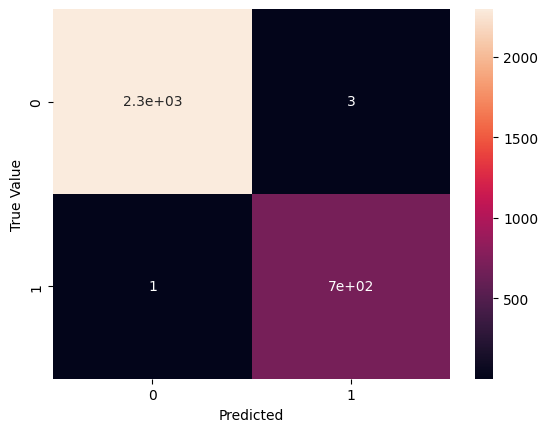

In [46]:
#plot the graph
from matplotlib import pyplot as plt
import seaborn as sn
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('True Value')
plt.show()